In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_dataset

ds = load_dataset("Alljoined/05_125")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/652 [00:00<?, ?B/s]

data/train-00000-of-00012.parquet:   0%|          | 0.00/376M [00:00<?, ?B/s]

data/train-00001-of-00012.parquet:   0%|          | 0.00/376M [00:00<?, ?B/s]

data/train-00002-of-00012.parquet:   0%|          | 0.00/376M [00:00<?, ?B/s]

...

data/test-00000-of-00003.parquet:   0%|          | 0.00/382M [00:00<?, ?B/s]

data/test-00001-of-00003.parquet:   0%|          | 0.00/382M [00:00<?, ?B/s]

data/test-00002-of-00003.parquet:   0%|          | 0.00/381M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/34354 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8716 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd
from datasets import load_dataset

# Load the dataset (ensuring 'ds' is defined in this cell's scope)
ds = load_dataset("Alljoined/05_125")

# Convert the 'train' split of the dataset to a pandas DataFrame
train_df = ds['train'].to_pandas()

# Save the DataFrame to a CSV file
train_output_path = './Alljoined_05_125_train.csv'
train_df.to_csv(train_output_path, index=False)

print(f"Train dataset saved to: {train_output_path}")

# You can do the same for the 'test' split
test_df = ds['test'].to_pandas()
test_output_path = './Alljoined_05_125_test.csv'
test_df.to_csv(test_output_path, index=False)

print(f"Test dataset saved to: {test_output_path}")

Train dataset saved to: ./Alljoined_05_125_train.csv
Test dataset saved to: ./Alljoined_05_125_test.csv


In [ ]:
import pandas as pd

train_path = '/content/Alljoined_05_125_train.csv'

# Read just the header
df_head = pd.read_csv(train_path, nrows=0)
print("Raw Columns in CSV:", df_head.columns.tolist())

# Strip spaces and print again
df_head.columns = df_head.columns.str.strip()
print("Cleaned Columns:", df_head.columns.tolist())

Raw Columns in CSV: ['EEG', 'subject_id', 'session', 'block', 'trial', '73k_id', 'coco_id', 'curr_time']
Cleaned Columns: ['EEG', 'subject_id', 'session', 'block', 'trial', '73k_id', 'coco_id', 'curr_time']


In [ ]:
import pandas as pd

# Load a small sample
df_sample = pd.read_csv('/content/Alljoined_05_125_train.csv', nrows=100)
df_sample.columns = df_sample.columns.str.strip()

print("Checking for potential Target columns:\n")

# Check unique values in columns that might be labels
potential_targets = ['subject_id', 'session', 'block', 'trial']

for col in potential_targets:
    if col in df_sample.columns:
        unique_vals = df_sample[col].unique()
        print(f"Column: '{col}'")
        print(f"  Unique Values ({len(unique_vals)}): {unique_vals[:10]}...") # Show first 10
        print("-" * 30)

Checking for potential Target columns:

Column: 'subject_id'
  Unique Values (1): [6]...
------------------------------
Column: 'session'
  Unique Values (1): [2]...
------------------------------
Column: 'block'
  Unique Values (1): [1]...
------------------------------
Column: 'trial'
  Unique Values (100): [ 1  2  3  4  5  6  8  9 10 11]...
------------------------------


In [ ]:
import os

# List all files in the /content/ directory
path = '/content/'
files = os.listdir(path)

print("Files found in /content/:")
for f in files:
    # Check file size
    size = os.path.getsize(os.path.join(path, f)) / (1024 * 1024) # MB
    print(f"- {f} ({size:.2f} MB)")

Files found in /content/:
- .config (0.00 MB)
- Alljoined_05_125_train.csv (13319.09 MB)
- Alljoined_05_125_test.csv (3379.20 MB)
- drive (0.00 MB)
- sample_data (0.00 MB)


In [ ]:
import pandas as pd

df = pd.read_csv('/content/Alljoined_05_125_train.csv', nrows=3)

print("First 3 rows of the 'EEG' column:")
print(df['EEG'])

First 3 rows of the 'EEG' column:
0    [array([ 4.17950650e-06,  9.88364036e-07, -1.9...
1    [array([-8.85235522e-07, -2.34426878e-07,  1.6...
2    [array([ 3.12916222e-06, -2.38300072e-06, -1.9...
Name: EEG, dtype: object


Initializing Pipeline...


Model: "ConvLSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 256, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64, 64)         │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64, 16)         │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 256, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 256, 1)         │           193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,465 (126.82 KB)

 Trainable params: 32,273 (126.07 KB)

 Non-trainable params: 192 (768.00 B)


Training Model...
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 94s 785ms/step - loss: 0.4047 - val_loss: 0.7941
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 829ms/step - loss: 0.2951 - val_loss: 0.4770
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 875ms/step - loss: 0.3245 - val_loss: 0.3385
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 95s 957ms/step - loss: 0.2682 - val_loss: 0.6252
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 831ms/step - loss: 0.1555 - val_loss: 0.3734
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 772ms/step - loss: 0.1552 - val_loss: 0.2337
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 775ms/step - loss: 0.1316 - val_loss: 0.2522
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 792ms/step - loss: 0.1177 - val_loss: 0.3207
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 817ms/step - loss: 0.1307 - val_loss: 0.5750
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 817ms/step - loss: 0.1744 - val_loss: 0.1889

Visualizing Reconstruction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step


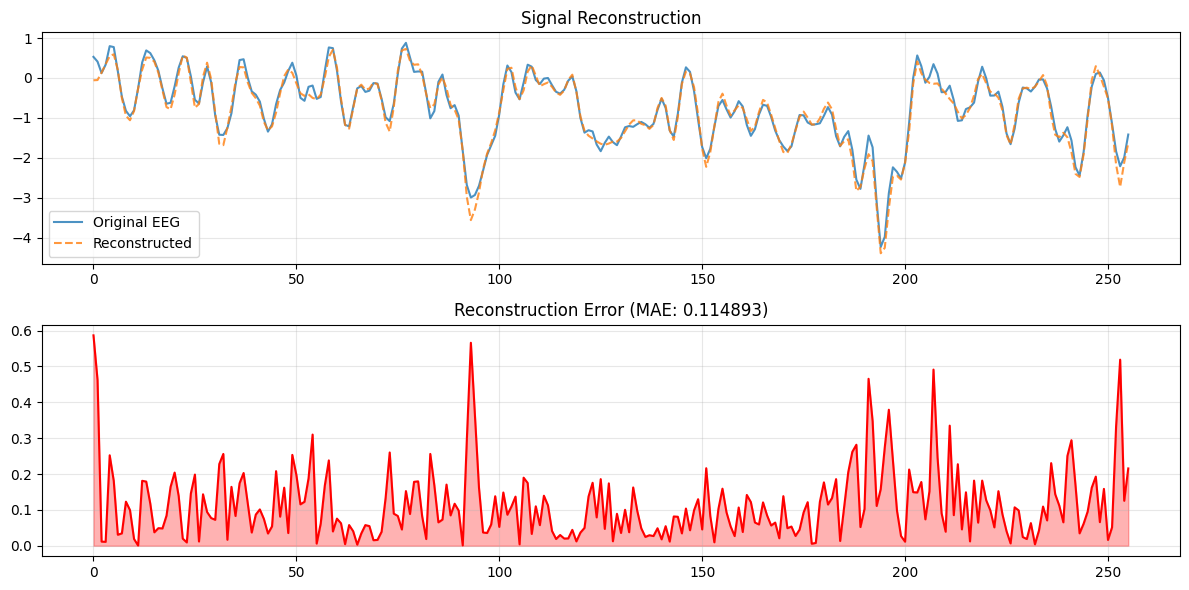

Mean Reconstruction Error for this batch: 0.2176905870437622


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.optimizers import Adam

# 1. DATA CLEANING FUNCTION (Fixed for Scientific Notation)
def parse_eeg_string(eeg_str):
    try:
        clean_str = str(eeg_str).replace('array(', '').replace(']', '').replace('[', '')
        # Regex handles scientific notation (e.g., 4.17e-06)
        numbers = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", clean_str)
        return np.array(numbers, dtype=np.float32)
    except:
        return np.zeros(256)

# 2. CONVLSTM AUTOENCODER ARCHITECTURE
def build_conv_lstm_autoencoder(input_shape):
    inputs = layers.Input(shape=input_shape)

    # --- ENCODER ---
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2, padding='same')(x)

    x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2, padding='same')(x)

    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)

    # Bottleneck
    latent = layers.Dense(16, activation='relu')(x)

    # --- DECODER ---
    x = layers.UpSampling1D(2)(latent)
    x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)

    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)

    outputs = layers.Conv1D(1, 3, activation='linear', padding='same')(x)

    model = models.Model(inputs, outputs, name="ConvLSTM_Autoencoder")
    return model

# 3. ROBUST GENERATOR
class RawEEGGenerator:
    def __init__(self, file_path, batch_size=32, timesteps=256):
        self.file_path = file_path
        self.batch_size = batch_size
        self.timesteps = timesteps

    def __call__(self):
        reader = pd.read_csv(self.file_path, chunksize=self.batch_size, on_bad_lines='skip')

        for chunk in reader:
            batch_data = []
            for eeg_str in chunk['EEG']:
                signal = parse_eeg_string(eeg_str)

                if np.std(signal) > 0:
                    signal = (signal - np.mean(signal)) / np.std(signal)

                # Resize logic
                if len(signal) < self.timesteps:
                    pad_width = self.timesteps - len(signal)
                    signal = np.pad(signal, (0, pad_width), mode='constant')
                else:
                    signal = signal[:self.timesteps]

                batch_data.append(signal)

            batch_data = np.array(batch_data)
            batch_data = batch_data.reshape(batch_data.shape[0], self.timesteps, 1)

            yield batch_data, batch_data

# 4. EXECUTION
train_path = '/content/Alljoined_05_125_train.csv'
test_path = '/content/Alljoined_05_125_test.csv'
BATCH_SIZE = 16
TIMESTEPS = 256
EPOCHS = 10

print("Initializing Pipeline...")

train_gen = RawEEGGenerator(train_path, batch_size=BATCH_SIZE, timesteps=TIMESTEPS)
test_gen = RawEEGGenerator(test_path, batch_size=BATCH_SIZE, timesteps=TIMESTEPS)

output_signature = (
    tf.TensorSpec(shape=(None, TIMESTEPS, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(None, TIMESTEPS, 1), dtype=tf.float32)
)

train_ds = tf.data.Dataset.from_generator(train_gen, output_signature=output_signature)
test_ds = tf.data.Dataset.from_generator(test_gen, output_signature=output_signature)

tf.keras.backend.clear_session()
model = build_conv_lstm_autoencoder((TIMESTEPS, 1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')
model.summary()

print("\nTraining Model...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    steps_per_epoch=100,
    validation_steps=20,
    verbose=1
)

# 5. VISUALIZATION (FIXED - No more .numpy() crash)
print("\nVisualizing Reconstruction...")

# Take one batch
for x_test, _ in test_ds.take(1):
    # Reconstruct
    reconstructions = model.predict(x_test)

    # Calculate Loss
    loss = np.mean(np.abs(reconstructions - x_test), axis=(1,2))

    # --- THE FIX ---
    # We use np.array() to safely convert BOTH Tensors and Arrays
    x_test_np = np.array(x_test[0]).flatten()
    recon_np = np.array(reconstructions[0]).flatten()

    plt.figure(figsize=(12, 6))

    # Plot 1: Signal vs Reconstruction
    plt.subplot(2, 1, 1)
    plt.plot(x_test_np, label='Original EEG', alpha=0.8)
    plt.plot(recon_np, label='Reconstructed', linestyle='--', alpha=0.8)
    plt.title("Signal Reconstruction")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Error
    plt.subplot(2, 1, 2)
    error = np.abs(x_test_np - recon_np)
    plt.plot(error, color='red')
    plt.fill_between(range(TIMESTEPS), error, color='red', alpha=0.3)
    plt.title(f"Reconstruction Error (MAE: {np.mean(error):.6f})")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Mean Reconstruction Error for this batch: {np.mean(loss)}")
    break


Generating Comprehensive Evaluation & Time-Domain Analysis...

 BATCH EVALUATION METRICS 
Batch Size               : 16 samples
Mean MAE (Reconstruction): 0.217691
Std Dev MAE              : 0.123832
RMSE                     : 0.307228
--------------------------------------------------
Dynamic Threshold (Mean+3SD): 0.589188
Potential Seizures Detected  : 1 / 16
Anomaly Ratio                 : 6.25%



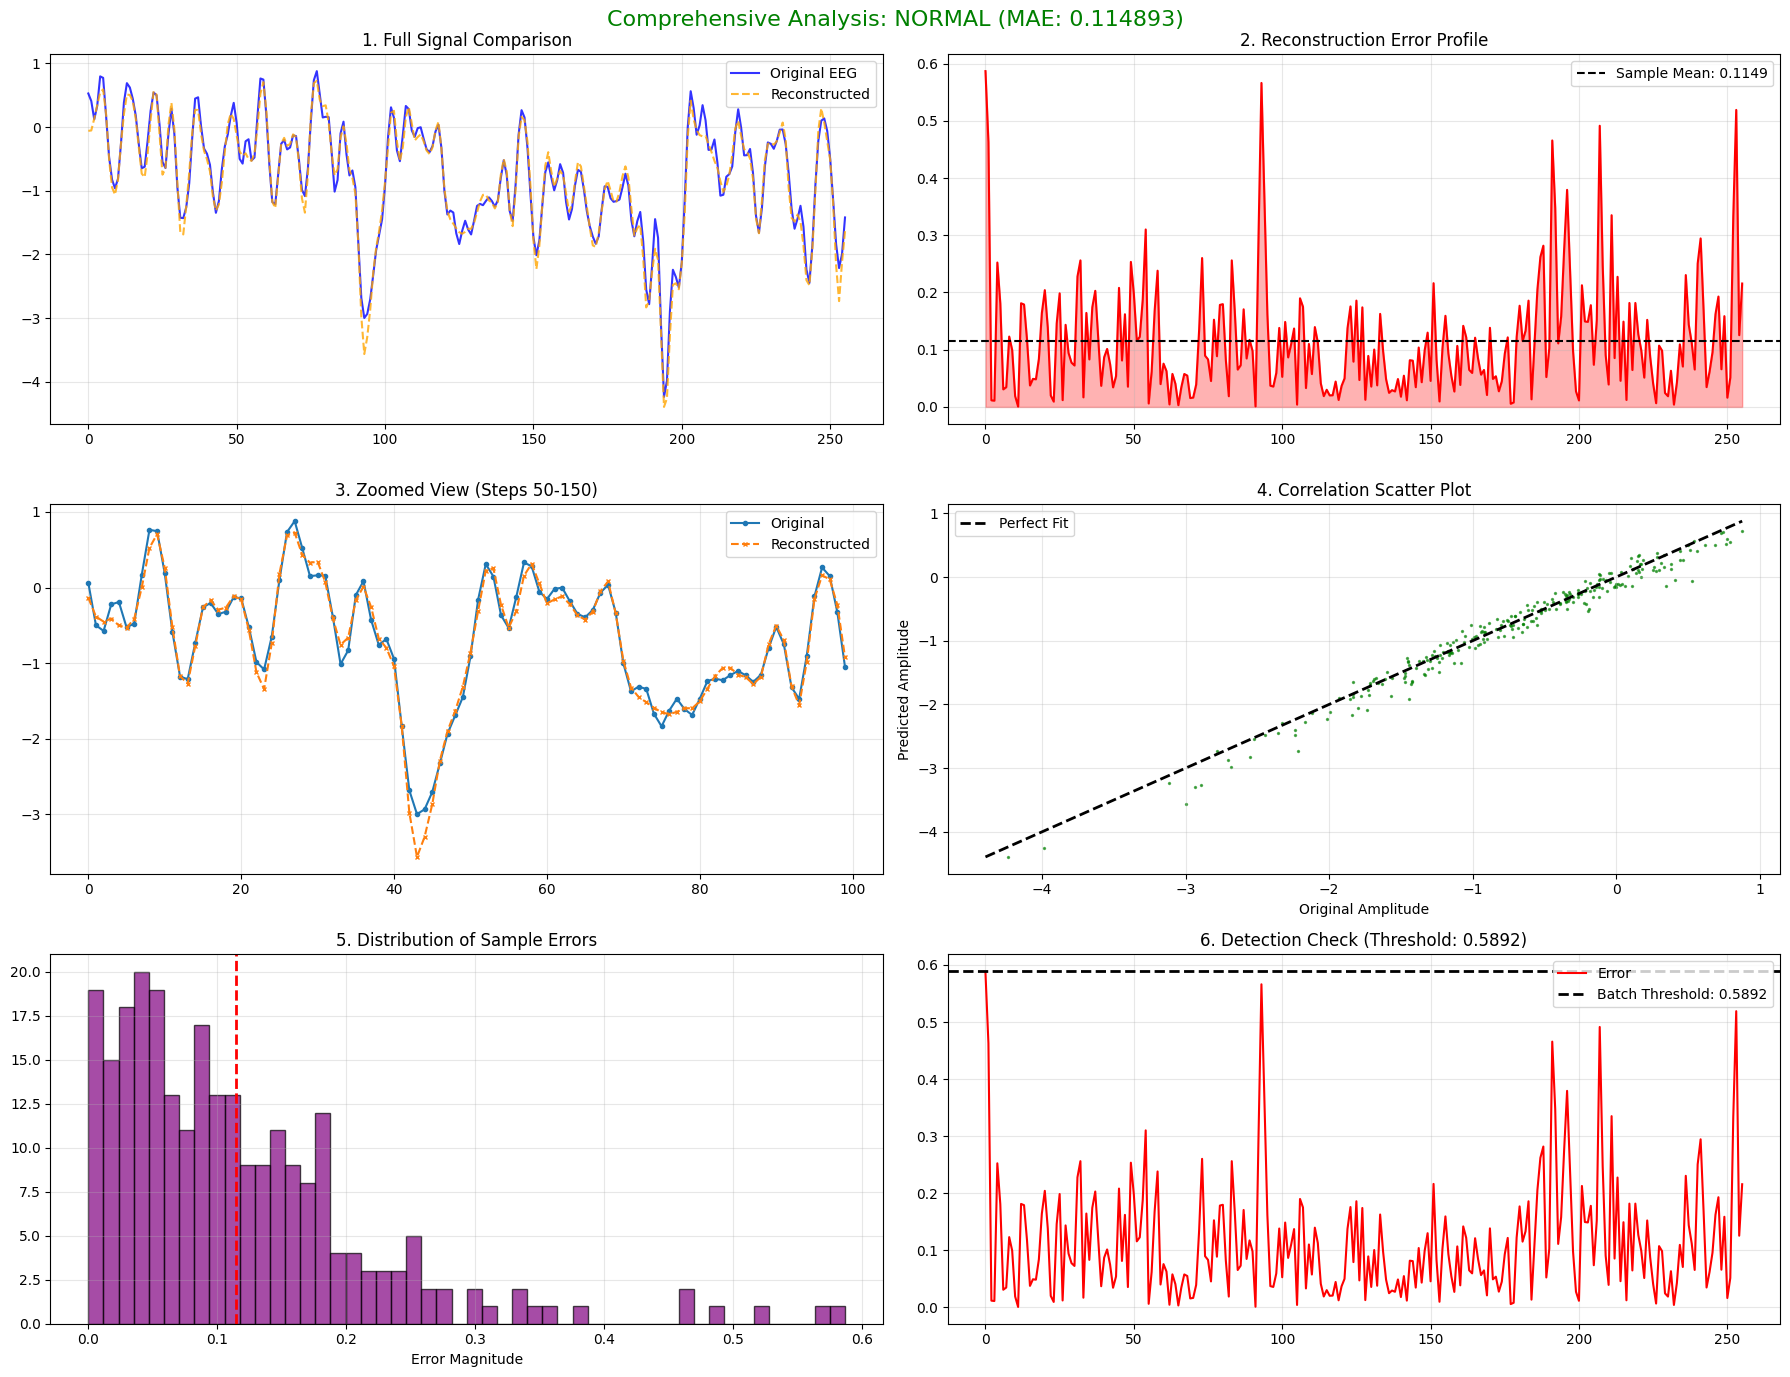

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 5. COMPREHENSIVE EVALUATION & TIME-DOMAIN VISUALIZATION
print("\nGenerating Comprehensive Evaluation & Time-Domain Analysis...")

def calculate_metrics_and_visualize(x_test, reconstructions, timesteps):
    # --- STEP 1: SAFE DATA CONVERSION ---
    x_np = np.array(x_test)      # Shape: (Batch, Timesteps, 1)
    r_np = np.array(reconstructions)

    # --- STEP 2: CALCULATE BATCH-LEVEL METRICS ---
    # MAE per sample
    mae_per_sample = np.mean(np.abs(r_np - x_np), axis=(1,2))
    # MSE per sample
    mse_per_sample = np.mean(np.square(r_np - x_np), axis=(1,2))

    # Aggregate Statistics
    avg_mae = np.mean(mae_per_sample)
    std_mae = np.std(mae_per_sample)
    avg_mse = np.mean(mse_per_sample)
    rmse = np.sqrt(avg_mse)

    # --- STEP 3: ANOMALY DETECTION LOGIC ---
    # Dynamic Threshold: Mean + 3 * Std Dev
    threshold = avg_mae + 3 * std_mae
    detections = np.sum(mae_per_sample > threshold)
    anomaly_ratio = (detections / len(mae_per_sample)) * 100

    # --- STEP 4: PRINT METRICS ---
    print("\n" + "="*50)
    print(" BATCH EVALUATION METRICS ")
    print("="*50)
    print(f"Batch Size               : {len(mae_per_sample)} samples")
    print(f"Mean MAE (Reconstruction): {avg_mae:.6f}")
    print(f"Std Dev MAE              : {std_mae:.6f}")
    print(f"RMSE                     : {rmse:.6f}")
    print("-"*50)
    print(f"Dynamic Threshold (Mean+3SD): {threshold:.6f}")
    print(f"Potential Seizures Detected  : {detections} / {len(mae_per_sample)}")
    print(f"Anomaly Ratio                 : {anomaly_ratio:.2f}%")
    print("="*50 + "\n")

    # --- STEP 5: VISUALIZATION (Focus on Sample 0) ---
    # Prepare data for the first sample for plotting
    x_samp = x_np[0].flatten()
    r_samp = r_np[0].flatten()
    error_samp = np.abs(x_samp - r_samp)
    is_anomaly = mae_per_sample[0] > threshold

    status = "ANOMALY DETECTED" if is_anomaly else "NORMAL"
    color_status = "red" if is_anomaly else "green"

    fig, axes = plt.subplots(3, 2, figsize=(18, 14))
    fig.suptitle(f"Comprehensive Analysis: {status} (MAE: {np.mean(error_samp):.6f})", fontsize=16, color=color_status)

    # PLOT 1: Full Signal
    axes[0, 0].plot(x_samp, label='Original EEG', color='blue', alpha=0.8)
    axes[0, 0].plot(r_samp, label='Reconstructed', color='orange', linestyle='--', alpha=0.8)
    axes[0, 0].set_title("1. Full Signal Comparison")
    axes[0, 0].legend(loc='upper right')
    axes[0, 0].grid(True, alpha=0.3)

    # PLOT 2: Error Profile
    axes[0, 1].plot(error_samp, color='red')
    axes[0, 1].fill_between(range(timesteps), error_samp, color='red', alpha=0.3)
    axes[0, 1].axhline(np.mean(error_samp), color='black', linestyle='--', label=f'Sample Mean: {np.mean(error_samp):.4f}')
    axes[0, 1].set_title("2. Reconstruction Error Profile")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # PLOT 3: Zoomed View
    zoom_start, zoom_end = 50, 150
    axes[1, 0].plot(x_samp[zoom_start:zoom_end], label='Original', marker='o', markersize=3)
    axes[1, 0].plot(r_samp[zoom_start:zoom_end], label='Reconstructed', marker='x', markersize=3, linestyle='--')
    axes[1, 0].set_title(f"3. Zoomed View (Steps {zoom_start}-{zoom_end})")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # PLOT 4: Scatter Correlation
    axes[1, 1].scatter(x_samp, r_samp, s=2, alpha=0.6, color='green')
    min_val, max_val = min(x_samp.min(), r_samp.min()), max(x_samp.max(), r_samp.max())
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Fit')
    axes[1, 1].set_title("4. Correlation Scatter Plot")
    axes[1, 1].set_xlabel("Original Amplitude")
    axes[1, 1].set_ylabel("Predicted Amplitude")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # PLOT 5: Error Histogram
    axes[2, 0].hist(error_samp, bins=50, color='purple', edgecolor='black', alpha=0.7)
    axes[2, 0].set_title("5. Distribution of Sample Errors")
    axes[2, 0].set_xlabel("Error Magnitude")
    axes[2, 0].axvline(np.mean(error_samp), color='red', linestyle='dashed', linewidth=2)
    axes[2, 0].grid(True, alpha=0.3)

    # PLOT 6: Detection Status
    axes[2, 1].plot(error_samp, label='Error', color='red')
    axes[2, 1].axhline(threshold, color='black', linestyle='--', linewidth=2, label=f'Batch Threshold: {threshold:.4f}')
    axes[2, 1].fill_between(range(timesteps), error_samp, threshold,
                             where=(error_samp > threshold),
                             color='orange', alpha=0.5)
    axes[2, 1].set_title(f"6. Detection Check (Threshold: {threshold:.4f})")
    axes[2, 1].legend(loc='upper right')
    axes[2, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- EXECUTE ---
# Get one batch from test set
for x_test, _ in test_ds.take(1):
    # Reconstruct
    reconstructions = model.predict(x_test, verbose=0)

    # Run Evaluation & Visualization
    calculate_metrics_and_visualize(x_test, reconstructions, TIMESTEPS)

    break

###OUR MODEL


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import re
from tensorflow.keras import layers, models, Model
from tensorflow.keras.optimizers import Adam

# --- FIX: CUSTOM LAYERS FOR SIGNAL OPERATIONS ---

class FFTLayer(layers.Layer):
    """
    Custom Keras Layer to perform FFT.
    Wraps tf.signal.rfft to be compatible with Keras 3.
    """
    def call(self, inputs):
        # Perform FFT
        fft_vals = tf.signal.rfft(inputs)
        # Split Real and Imaginary parts
        real = tf.math.real(fft_vals)
        imag = tf.math.imag(fft_vals)
        # Stack to create 2 channels (Real, Imag)
        return tf.stack([real, imag], axis=-1)

class IFFTLayer(layers.Layer):
    """
    Custom Keras Layer to perform Inverse FFT.
    Wraps tf.signal.irfft to be compatible with Keras 3.
    """
    def __init__(self, timesteps, **kwargs):
        super().__init__(**kwargs)
        self.timesteps = timesteps

    def call(self, inputs):
        # Unstack Real and Imaginary
        real = inputs[:, :, 0]
        imag = inputs[:, :, 1]
        # Recombine into Complex tensor
        spec_recon = tf.complex(real, imag)
        # Perform Inverse FFT to get back to Time Domain
        return tf.signal.irfft(spec_recon, fft_length=[self.timesteps])

# 1. DATA PARSER
def parse_eeg_fast(eeg_str):
    try:
        clean_str = str(eeg_str).replace('[', '').replace(']', '').replace('array(', '').replace(')', '').replace('\n', ' ')
        return np.array(re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", clean_str), dtype=np.float32)
    except:
        return np.zeros(512)

# 2. GENERATOR
class SpectralGenerator:
    def __init__(self, file_path, batch_size=16, timesteps=512):
        self.file_path = file_path
        self.batch_size = batch_size
        self.timesteps = timesteps

    def __call__(self):
        reader = pd.read_csv(self.file_path, chunksize=self.batch_size, on_bad_lines='skip')
        for chunk in reader:
            batch = []
            for s in chunk['EEG']:
                sig = parse_eeg_fast(s)
                if np.std(sig) > 0:
                    sig = (sig - np.mean(sig)) / np.std(sig)
                if len(sig) < self.timesteps:
                    sig = np.pad(sig, (0, self.timesteps - len(sig)), 'constant')
                else:
                    sig = sig[:self.timesteps]
                batch.append(sig)
            yield np.array(batch, dtype=np.float32), np.array(batch, dtype=np.float32)

# 3. SE-RESNET BLOCKS
def se_block(input_tensor, reduction=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling1D()(input_tensor)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, filters))(se)
    return layers.multiply([input_tensor, se])

def residual_block_freq(x, filters):
    shortcut = layers.Dense(filters)(x)
    x = layers.Dense(filters, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(filters, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return layers.add([x, shortcut])

# 4. MAIN MODEL ARCHITECTURE
def build_spectral_se_resnet(timesteps):
    # Input Layer (Must be a tuple)
    inputs = layers.Input(shape=(timesteps,))

    # --- ENCODER (Using Custom FFT Layer) ---
    # Use FFTLayer instead of tf.signal.rfft
    x = FFTLayer()(inputs)

    # SE-ResNet Blocks
    x = layers.Dense(128)(x)
    x = se_block(x)
    x = residual_block_freq(x, 128)

    x = layers.Dense(64)(x)
    x = se_block(x)
    x = residual_block_freq(x, 64)

    x = layers.Dense(32)(x)
    x = se_block(x)

    # --- DECODER (Using Custom IFFT Layer) ---
    x = layers.Dense(2)(x)
    # Use IFFTLayer instead of tf.signal.irfft
    outputs = IFFTLayer(timesteps)(x)

    return Model(inputs, outputs, name="Spectral_SE_ResNet_Detector")

print("Architecture Defined Successfully.")

Architecture Defined Successfully.


In [ ]:
# Configuration
train_path = '/content/Alljoined_05_125_train.csv'
test_path = '/content/Alljoined_05_125_test.csv'
TIMESTEPS = 512
BATCH_SIZE = 16
EPOCHS = 20

print("Initializing Pipeline...")
train_gen = SpectralGenerator(train_path, BATCH_SIZE, TIMESTEPS)
test_gen = SpectralGenerator(test_path, BATCH_SIZE, TIMESTEPS)

output_sig = (tf.TensorSpec(shape=(None, TIMESTEPS), dtype=tf.float32),
              tf.TensorSpec(shape=(None, TIMESTEPS), dtype=tf.float32))

train_ds = tf.data.Dataset.from_generator(train_gen, output_signature=output_sig)
test_ds = tf.data.Dataset.from_generator(test_gen, output_signature=output_sig)

tf.keras.backend.clear_session()

# Build & Compile
model = build_spectral_se_resnet(TIMESTEPS)
model.compile(optimizer=Adam(0.0005), loss='mae')

print("\nTraining Spectral Model...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    steps_per_epoch=200,
    validation_steps=50,
    verbose=1
)

print("Training Complete.")

Initializing Pipeline...

Training Spectral Model...
Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 206s 950ms/step - loss: 0.1088 - val_loss: 0.0536
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 173s 867ms/step - loss: 0.0240 - val_loss: 0.0800
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 174s 871ms/step - loss: 0.0108 - val_loss: 0.0081
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 188s 946ms/step - loss: 0.0056 - val_loss: 0.0142
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 180s 902ms/step - loss: 0.0079 - val_loss: 0.0076
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 180s 905ms/step - loss: 0.0081 - val_loss: 0.0093
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 170s 854ms/step - loss: 0.0090 - val_loss: 0.0166
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 192s 962ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 164s 825ms/step - loss: 0.0031 - val_loss: 0.0043
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 179s 898ms/step - loss: 0.0040 - val_loss: 0.0034
Epoch 11/20
147/200 ━━━━━━━━━━━━━━━━━━━━ 25s 4

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 105s 526ms/step - loss: 0.0038 - val_loss: 0.0060
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 183s 914ms/step - loss: 0.0051 - val_loss: 0.0101
Epoch 13/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 174s 873ms/step - loss: 0.0160 - val_loss: 0.0060
Epoch 14/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 177s 890ms/step - loss: 0.0046 - val_loss: 0.0051
Epoch 15/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - loss: 0.0033 - val_loss: 0.0031
Epoch 16/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 181s 910ms/step - loss: 0.0054 - val_loss: 0.0070
Epoch 17/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 191s 959ms/step - loss: 0.0069 - val_loss: 0.0057
Epoch 18/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 187s 937ms/step - loss: 0.0078 - val_loss: 0.0069
Epoch 19/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 171s 858ms/step - loss: 0.0030 - val_loss: 0.0044
Epoch 20/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 180s 905ms/step - loss: 0.0026 - val_loss: 0.0045
Training Complete.



Generating Spectral Model Evaluation & Visualization...

 SPECTRAL MODEL EVALUATION METRICS 
Batch Size               : 16 samples
Mean MAE (Reconstruction): 0.004378
Std Dev MAE              : 0.000896
RMSE                     : 0.005542
--------------------------------------------------
Dynamic Threshold (Mean+3SD): 0.007065
Potential Seizures Detected  : 0 / 16
Anomaly Ratio                 : 0.00%



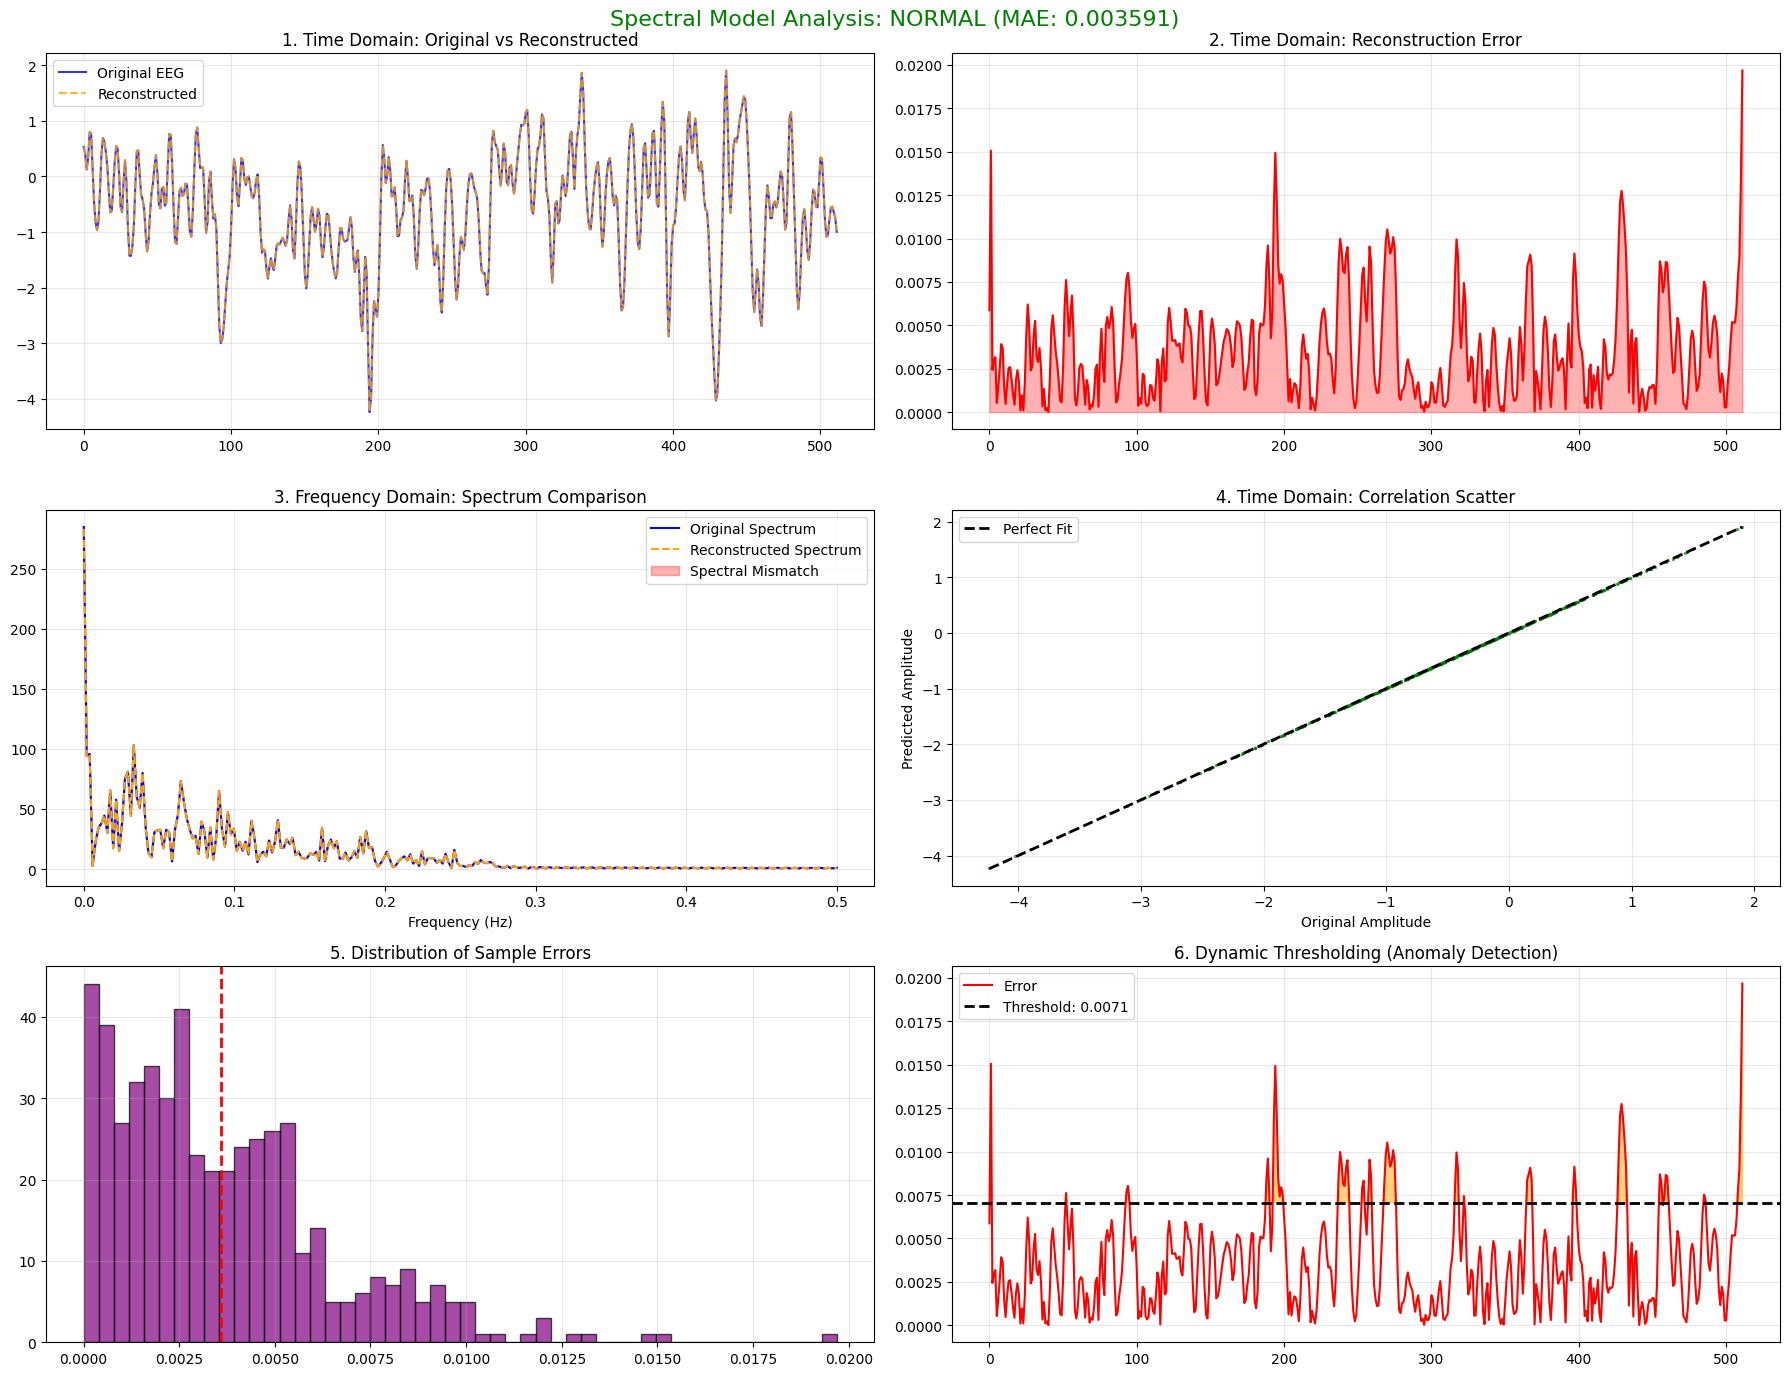

In [ ]:
import matplotlib.pyplot as plt

print("\nGenerating Spectral Model Evaluation & Visualization...")

def evaluate_spectral_model(x_test, reconstructions, timesteps):
    # --- SAFE CONVERSION ---
    x_np = np.array(x_test)
    r_np = np.array(reconstructions)

    # --- FIX: METRICS CALCULATION ---
    # Since Spectral model input is (Batch, 512) [2D], we only reduce over axis=1 (Timesteps).
    # The previous code used axis=(1,2) which assumes 3D data (Batch, Timesteps, Channels).

    mae_per_sample = np.mean(np.abs(r_np - x_np), axis=1)
    mse_per_sample = np.mean(np.square(r_np - x_np), axis=1)

    avg_mae = np.mean(mae_per_sample)
    std_mae = np.std(mae_per_sample)
    avg_mse = np.mean(mse_per_sample)
    rmse = np.sqrt(avg_mse)

    # --- ANOMALY DETECTION LOGIC ---
    threshold = avg_mae + 3 * std_mae
    detections = np.sum(mae_per_sample > threshold)
    anomaly_ratio = (detections / len(mae_per_sample)) * 100

    # --- PRINT METRICS ---
    print("\n" + "="*50)
    print(" SPECTRAL MODEL EVALUATION METRICS ")
    print("="*50)
    print(f"Batch Size               : {len(mae_per_sample)} samples")
    print(f"Mean MAE (Reconstruction): {avg_mae:.6f}")
    print(f"Std Dev MAE              : {std_mae:.6f}")
    print(f"RMSE                     : {rmse:.6f}")
    print("-"*50)
    print(f"Dynamic Threshold (Mean+3SD): {threshold:.6f}")
    print(f"Potential Seizures Detected  : {detections} / {len(mae_per_sample)}")
    print(f"Anomaly Ratio                 : {anomaly_ratio:.2f}%")
    print("="*50 + "\n")

    # --- VISUALIZATION ---
    # Since x_np is 2D (Batch, 512), we flatten it directly.
    x_samp = x_np[0].flatten()
    r_samp = r_np[0].flatten()
    error_samp = np.abs(x_samp - r_samp)

    is_anomaly = mae_per_sample[0] > threshold
    status = "ANOMALY DETECTED" if is_anomaly else "NORMAL"
    color_status = "red" if is_anomaly else "green"

    fig, axes = plt.subplots(3, 2, figsize=(18, 14))
    fig.suptitle(f"Spectral Model Analysis: {status} (MAE: {np.mean(error_samp):.6f})", fontsize=16, color=color_status)

    # PLOT 1: Time Domain Reconstruction
    axes[0, 0].plot(x_samp, label='Original EEG', color='blue', alpha=0.8)
    axes[0, 0].plot(r_samp, label='Reconstructed', color='orange', linestyle='--', alpha=0.8)
    axes[0, 0].set_title("1. Time Domain: Original vs Reconstructed")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # PLOT 2: Time Domain Error
    axes[0, 1].plot(error_samp, color='red')
    axes[0, 1].fill_between(range(timesteps), error_samp, color='red', alpha=0.3)
    axes[0, 1].set_title("2. Time Domain: Reconstruction Error")
    axes[0, 1].grid(True, alpha=0.3)

    # PLOT 3: FREQUENCY DOMAIN SPECTRUM
    spec_orig = np.abs(np.fft.rfft(x_samp))
    spec_recon = np.abs(np.fft.rfft(r_samp))
    freqs = np.fft.rfftfreq(timesteps)

    axes[1, 0].plot(freqs, spec_orig, label='Original Spectrum', color='blue')
    axes[1, 0].plot(freqs, spec_recon, label='Reconstructed Spectrum', color='orange', linestyle='--')
    axes[1, 0].fill_between(freqs, spec_orig, spec_recon, color='red', alpha=0.3, label='Spectral Mismatch')
    axes[1, 0].set_title("3. Frequency Domain: Spectrum Comparison")
    axes[1, 0].set_xlabel("Frequency (Hz)")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # PLOT 4: Scatter Correlation
    axes[1, 1].scatter(x_samp, r_samp, s=2, alpha=0.6, color='green')
    min_val, max_val = min(x_samp.min(), r_samp.min()), max(x_samp.max(), r_samp.max())
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Fit')
    axes[1, 1].set_title("4. Time Domain: Correlation Scatter")
    axes[1, 1].set_xlabel("Original Amplitude")
    axes[1, 1].set_ylabel("Predicted Amplitude")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # PLOT 5: Error Histogram
    axes[2, 0].hist(error_samp, bins=50, color='purple', edgecolor='black', alpha=0.7)
    axes[2, 0].set_title("5. Distribution of Sample Errors")
    axes[2, 0].axvline(np.mean(error_samp), color='red', linestyle='dashed', linewidth=2)
    axes[2, 0].grid(True, alpha=0.3)

    # PLOT 6: Dynamic Thresholding
    axes[2, 1].plot(error_samp, label='Error', color='red')
    axes[2, 1].axhline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
    axes[2, 1].fill_between(range(timesteps), error_samp, threshold,
                             where=(error_samp > threshold),
                             color='orange', alpha=0.5)
    axes[2, 1].set_title("6. Dynamic Thresholding (Anomaly Detection)")
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- EXECUTE EVALUATION ---
for x_test, _ in test_ds.take(1):
    reconstructions = model.predict(x_test, verbose=0)
    evaluate_spectral_model(x_test, reconstructions, TIMESTEPS)
    break


ANALYZING: Spectral SE-ResNet
Batch Size          : 16
Dynamic Threshold   : 0.007065
Detected Anomalies  : 0
Worst Sample Index  : 14 (Error: 0.006680)



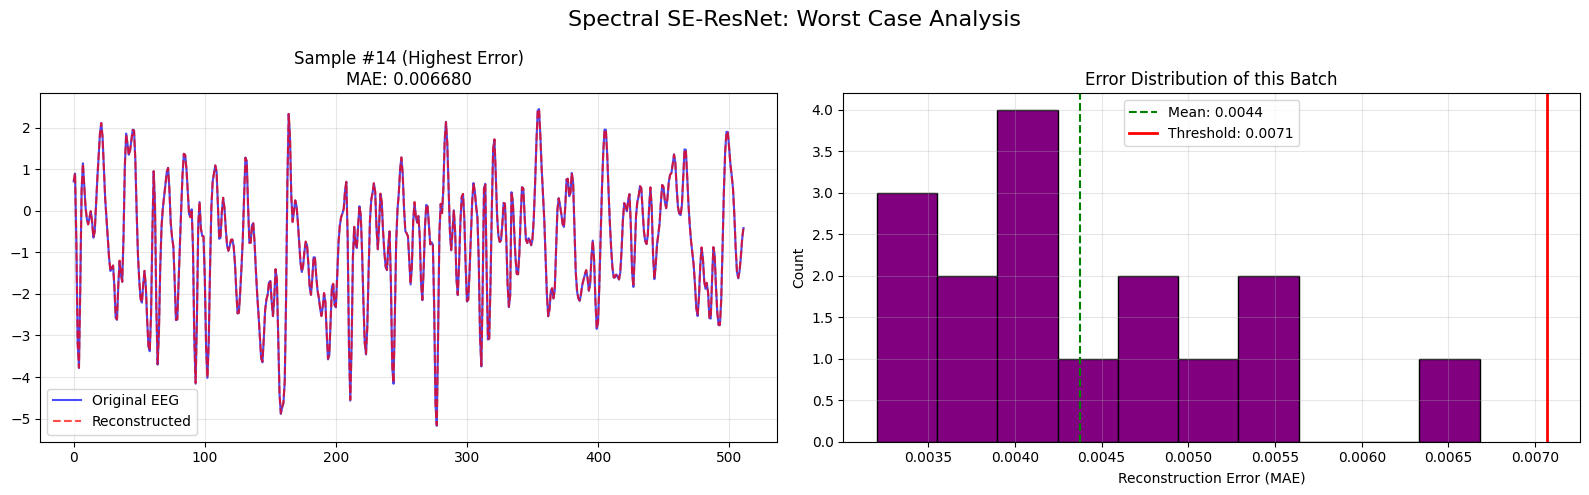

=> RESULT: No anomalies detected.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_model_robustly(model, test_ds, model_name, timesteps):
    """
    Analyzes a model by finding the 'Worst Case' reconstruction in a batch
    and visualizing the error distribution.
    """
    print(f"\n{'='*60}")
    print(f"ANALYZING: {model_name}")
    print(f"{'='*60}")

    # 1. Get one batch of data
    for x_batch, _ in test_ds.take(1):
        # 2. Predict
        preds = model.predict(x_batch, verbose=0)

        # 3. Safe Conversion
        x_np = np.array(x_batch)
        p_np = np.array(preds)

        # 4. Calculate Metrics (Handles both 2D and 3D shapes automatically)
        # ConvLSTM is (Batch, Time, 1) -> 3D. Spectral is (Batch, Time) -> 2D.
        if x_np.ndim == 3:
            # Average over Timesteps and Channels
            mae_per_sample = np.mean(np.abs(p_np - x_np), axis=(1,2))
            # Flatten for plotting
            x_flat = x_np.reshape(x_np.shape[0], -1)
            p_flat = p_np.reshape(p_np.shape[0], -1)
        else:
            # Average over Timesteps only
            mae_per_sample = np.mean(np.abs(p_np - x_np), axis=1)
            x_flat = x_np
            p_flat = p_np

        # 5. Statistics
        avg_mae = np.mean(mae_per_sample)
        std_mae = np.std(mae_per_sample)
        threshold = avg_mae + 3 * std_mae
        detections = np.sum(mae_per_sample > threshold)

        # Find the WORST sample (highest error)
        worst_idx = np.argmax(mae_per_sample)
        worst_error = mae_per_sample[worst_idx]

        print(f"Batch Size          : {len(mae_per_sample)}")
        print(f"Dynamic Threshold   : {threshold:.6f}")
        print(f"Detected Anomalies  : {detections}")
        print(f"Worst Sample Index  : {worst_idx} (Error: {worst_error:.6f})")
        print(f"{'='*60}\n")

        # 6. VISUALIZATION
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle(f"{model_name}: Worst Case Analysis", fontsize=16)

        # --- PLOT 1: The Worst Sample ---
        # Extract the worst sample
        orig_samp = x_flat[worst_idx]
        recon_samp = p_flat[worst_idx]

        axes[0].plot(orig_samp, label='Original EEG', color='blue', alpha=0.7)
        axes[0].plot(recon_samp, label='Reconstructed', color='red', linestyle='--', alpha=0.7)
        axes[0].set_title(f"Sample #{worst_idx} (Highest Error)\nMAE: {worst_error:.6f}")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].fill_between(range(len(orig_samp)), orig_samp, recon_samp, color='orange', alpha=0.2)

        # --- PLOT 2: Error Distribution (Histogram) ---
        axes[1].hist(mae_per_sample, bins=10, color='purple', edgecolor='black')
        axes[1].axvline(avg_mae, color='green', linestyle='--', label=f'Mean: {avg_mae:.4f}')
        axes[1].axvline(threshold, color='red', linestyle='-', linewidth=2, label=f'Threshold: {threshold:.4f}')
        axes[1].set_title("Error Distribution of this Batch")
        axes[1].set_xlabel("Reconstruction Error (MAE)")
        axes[1].set_ylabel("Count")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # 7. QUICK TEXT INSIGHT
        if detections == 0:
            print("=> RESULT: No anomalies detected.")

        else:
            print(f"=> RESULT: {detections} anomalies detected.")

        break

# ==========================================
# RUN THIS FOR SPECTRAL MODEL
# ==========================================
analyze_model_robustly(
    model=model,              # The Spectral model (from Cell 2)
    test_ds=test_ds,          # The test dataset (defined in Cell 2)
    model_name="Spectral SE-ResNet",
    timesteps=512
)



Generating Unsupervised Evaluation Metrics...
Loading data for evaluation...
Predicting reconstructions...

 UNSUPERVISED EVALUATION METRICS 
1. RECONSTRUCTION FIDELITY (Model Performance)
   Mean Absolute Error (MAE)      : 0.004352
   Root Mean Squared Error (RMSE)  : 0.005726
   Inertia (Sum of Squared Errors) : 0.0164
------------------------------------------------------------
2. ERROR DISTRIBUTION STATISTICS (Anomaly Detection Quality)
   Skewness  : 2.0064
   Interpretation: Good (Tail to the right)
   Kurtosis  : 9.9260
   Interpretation: Good (Heavy tails = distinct anomalies)
------------------------------------------------------------
3. SEPARATION (IQR Method)
   Dynamic Threshold (Q3 + 1.5*IQR) : 0.007706
   Potential Anomalies Detected     : 20 / 500 (4.0%)


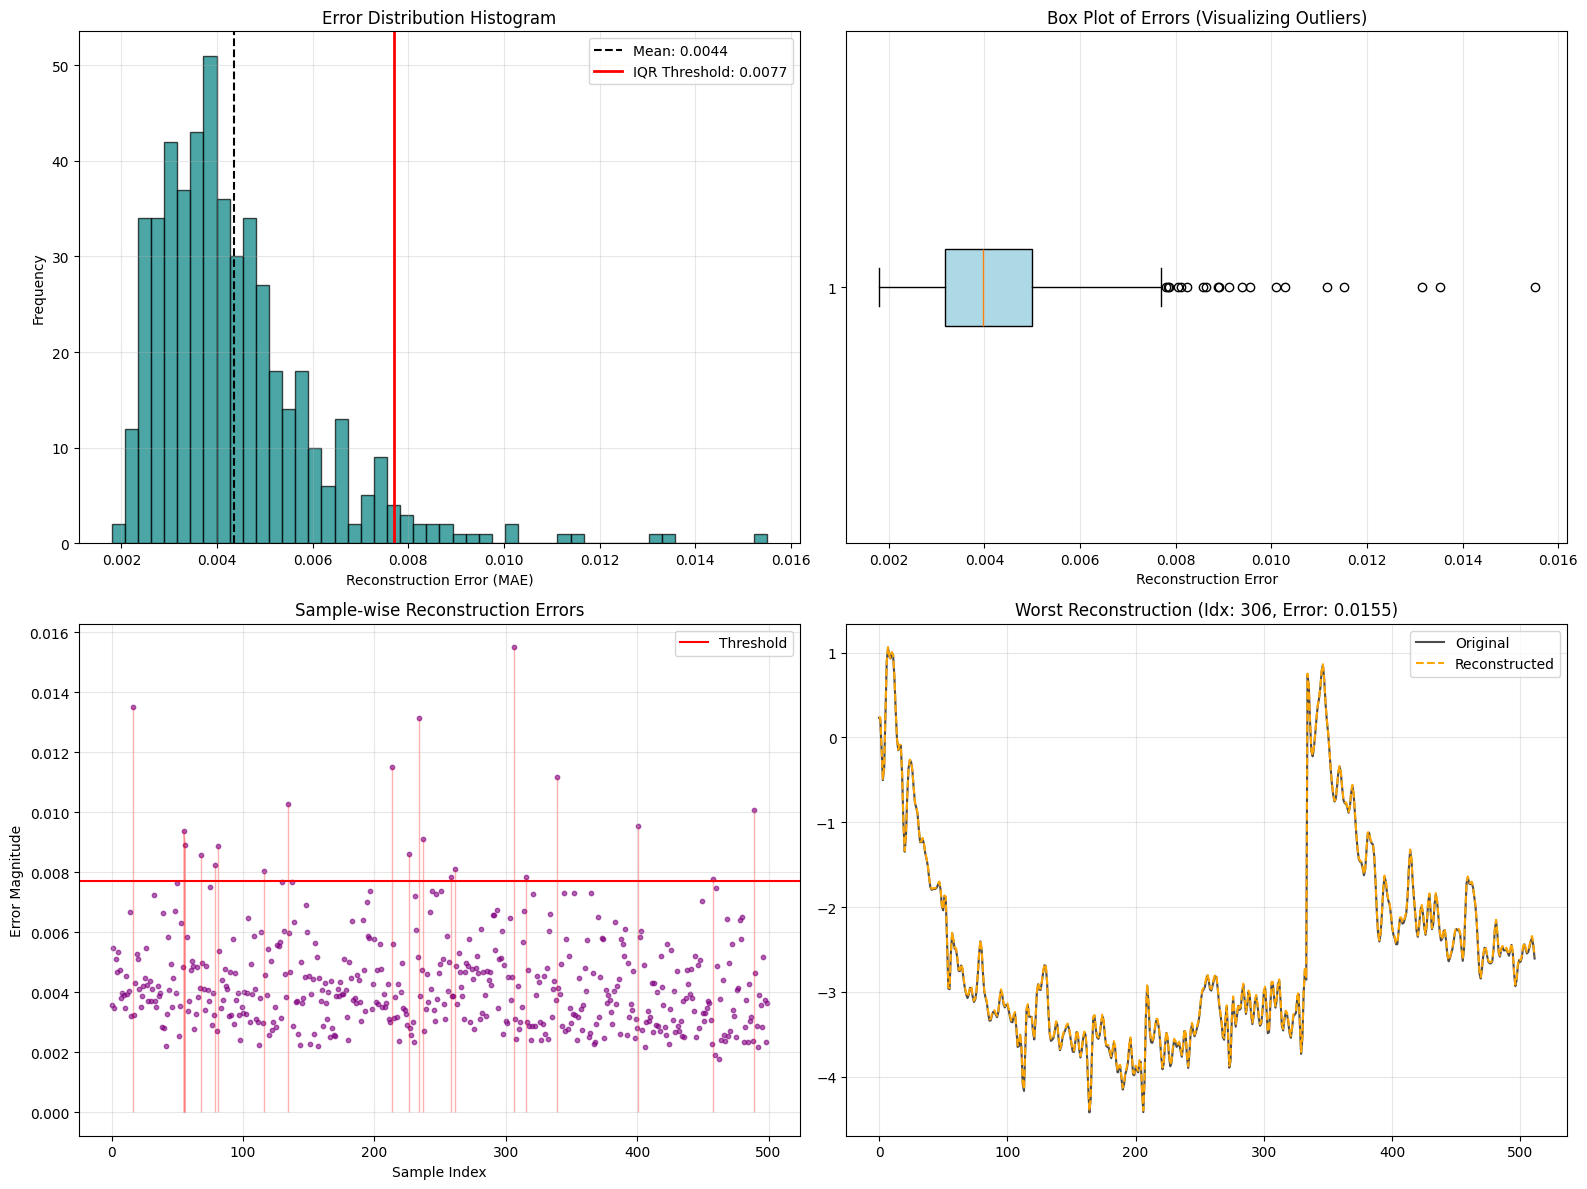

In [ ]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from scipy import stats
import tensorflow as tf

print("Generating Unsupervised Evaluation Metrics...")

# --- 1. LOAD DATA (Using the clean method) ---
def load_data_clean(path, num_samples=500):
    print("Loading data for evaluation...")
    df = pd.read_csv(path, nrows=num_samples, on_bad_lines='skip')
    batch = []
    for eeg_str in df['EEG']:
        clean_str = str(eeg_str).replace('[', '').replace(']', '').replace('array(', '').replace(')', '').replace('\n', ' ')
        sig = np.array(re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", clean_str), dtype=np.float32)
        if np.std(sig) > 0: sig = (sig - np.mean(sig)) / np.std(sig)
        if len(sig) < 512: sig = np.pad(sig, (0, 512 - len(sig)), 'constant')
        else: sig = sig[:512]
        batch.append(sig)
    return np.array(batch)

x_data = load_data_clean('/content/Alljoined_05_125_test.csv', num_samples=500)

# --- 2. PREDICT ---
print("Predicting reconstructions...")
preds = model.predict(x_data, verbose=0)

# --- 3. CALCULATE RECONSTRUCTION ERRORS ---
# Flatten for calculation
x_flat = x_data.reshape(x_data.shape[0], -1)
p_flat = preds.reshape(preds.shape[0], -1)
errors = np.mean(np.abs(x_flat - p_flat), axis=1) # MAE per sample
squared_errors = np.mean(np.square(x_flat - p_flat), axis=1)

# --- 4. CALCULATE UNSUPERVISED METRICS ---

# 1. Reconstruction Metrics (Lower is Better)
mae = np.mean(errors)
rmse = np.sqrt(np.mean(squared_errors))
inertia = np.sum(squared_errors) # Sum of Squared Errors

# 2. Statistical Metrics (Distribution Shape)
# Skewness: > 0 is good (Long tail of high errors indicates anomalies)
skewness = stats.skew(errors)
# Kurtosis: > 3 is good (Heavy tails indicate clear outliers)
kurtosis = stats.kurtosis(errors, fisher=False) # Fisher=False gives 3.0 for Normal dist

# 3. Threshold Identification (IQR Method)
q25, q75 = np.percentile(errors, [25, 75])
iqr = q75 - q25
threshold_iqr = q75 + (1.5 * iqr)
potential_anomalies = np.sum(errors > threshold_iqr)

# --- 5. PRINT METRICS ---
print("\n" + "="*60)
print(" UNSUPERVISED EVALUATION METRICS ")
print("="*60)
print("1. RECONSTRUCTION FIDELITY (Model Performance)")
print(f"   Mean Absolute Error (MAE)      : {mae:.6f}")
print(f"   Root Mean Squared Error (RMSE)  : {rmse:.6f}")
print(f"   Inertia (Sum of Squared Errors) : {inertia:.4f}")
print("-"*60)
print("2. ERROR DISTRIBUTION STATISTICS (Anomaly Detection Quality)")
print(f"   Skewness  : {skewness:.4f}")
print(f"   Interpretation: {'Good (Tail to the right)' if skewness > 0 else 'Bad (Symmetric, no clear outliers)'}")
print(f"   Kurtosis  : {kurtosis:.4f}")
print(f"   Interpretation: {'Good (Heavy tails = distinct anomalies)' if kurtosis > 3 else 'Normal (Flat distribution)'}")
print("-"*60)
print("3. SEPARATION (IQR Method)")
print(f"   Dynamic Threshold (Q3 + 1.5*IQR) : {threshold_iqr:.6f}")
print(f"   Potential Anomalies Detected     : {potential_anomalies} / {len(errors)} ({(potential_anomalies/len(errors))*100:.1f}%)")
print("="*60)

# --- 6. VISUALIZATION ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Histogram of Errors (The most important Unsupervised Viz)
axes[0, 0].hist(errors, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(mae, color='black', linestyle='--', label=f'Mean: {mae:.4f}')
axes[0, 0].axvline(threshold_iqr, color='red', linestyle='-', linewidth=2, label=f'IQR Threshold: {threshold_iqr:.4f}')
axes[0, 0].set_title('Error Distribution Histogram')
axes[0, 0].set_xlabel('Reconstruction Error (MAE)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Box Plot (Visualizing Outliers)
axes[0, 1].boxplot(errors, vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[0, 1].set_title('Box Plot of Errors (Visualizing Outliers)')
axes[0, 1].set_xlabel('Reconstruction Error')
axes[0, 1].grid(True, axis='x', alpha=0.3)

# Plot 3: Reconstruction Scatter (Error vs Sample Index)
axes[1, 0].scatter(range(len(errors)), errors, s=10, c='purple', alpha=0.6)
axes[1, 0].axhline(threshold_iqr, color='red', linestyle='-', label='Threshold')
axes[1, 0].fill_between(range(len(errors)), 0, errors, where=(errors > threshold_iqr), color='red', alpha=0.3)
axes[1, 0].set_title('Sample-wise Reconstruction Errors')
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('Error Magnitude')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Worst Case Reconstruction
worst_idx = np.argmax(errors)
orig = x_flat[worst_idx]
recon = p_flat[worst_idx]

axes[1, 1].plot(orig, label='Original', color='black', alpha=0.7)
axes[1, 1].plot(recon, label='Reconstructed', color='orange', linestyle='--')
axes[1, 1].set_title(f"Worst Reconstruction (Idx: {worst_idx}, Error: {errors[worst_idx]:.4f})")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()